# Задача 2

In [ ]:
!pip install statsforecast

In [ ]:
# imports
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA, AutoETS, AutoTheta, SeasonalNaive
from statsforecast.utils import AirPassengers as ap # (не используется, но часть импортов sf)

In [ ]:
# Constants
DIR_TASK1="task1_outputs"
DIR_TASK2="task2_outputs"
RANDOM_STATE=42
CSV="time_series_60min_singleindex.csv"
LAGS=[1, 24, 48, 168]
ROLLS=[24, 168]
EQUALS=50
COL_DS="ds"
COL_Y="y"

In [ ]:
# Отключаем предупреждения
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Создаем директорию для сохранения результатов
Path(DIR_TASK2).mkdir(parents=True, exist_ok=True)

## 2.1 ПОДГОТОВКА ДАННЫХ ПОД СТАНДАРТ STATSPORCAST

In [ ]:
df_train = pd.read_csv(f"{DIR_TASK1}/train.csv")
df_test = pd.read_csv(f"{DIR_TASK1}/test_clean.csv")

In [ ]:
train = df_train.copy()
test = df_test.copy()

In [ ]:
train.head(3)

,ds,y,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lag_1,lag_24,lag_48,lag_168,roll_mean_24,roll_mean_168,roll_std_24
0,2015-01-08 01:00:00+00:00,64676.0,1,3,1,0,0.258819,0.965926,0.5,0.866025,65948.0,66393.0,66811.0,69773.0,73511.708333,67914.946429,5870.788788
1,2015-01-08 02:00:00+00:00,61551.0,2,3,1,0,0.500000,0.866025,0.5,0.866025,64676.0,63640.0,64040.0,66417.0,73424.666667,67885.982143,6036.655392
2,2015-01-08 03:00:00+00:00,60541.0,3,3,1,0,0.707107,0.707107,0.5,0.866025,61551.0,62955.0,63275.0,64182.0,73324.083333,67864.309524,6235.522118


In [ ]:
test.head(3)

,Unnamed: 0,ds,y
0,40066,2019-07-28 09:00:00+00:00,39988.0
1,40067,2019-07-28 10:00:00+00:00,41946.0
2,40068,2019-07-28 11:00:00+00:00,40636.0


In [ ]:
df_sf = train[["ds", "y"]].copy()
df_sf

,ds,y
0,2015-01-08 01:00:00+00:00,64676.0
1,2015-01-08 02:00:00+00:00,61551.0
2,2015-01-08 03:00:00+00:00,60541.0
3,2015-01-08 04:00:00+00:00,62833.0
4,2015-01-08 05:00:00+00:00,68782.0
...,...,...
39891,2019-07-28 04:00:00+00:00,31636.0
39892,2019-07-28 05:00:00+00:00,32288.0
39893,2019-07-28 06:00:00+00:00,34240.0
39894,2019-07-28 07:00:00+00:00,36636.0


In [ ]:
df_sf.dtypes

,0
ds,object
y,float64


In [ ]:
# StatsForecast требует строгие колонки: unique_id, ds, y
df_sf["unique_id"] = "FR_Load"
df_sf["ds"] = pd.to_datetime(df_sf["ds"])
df_sf = df_sf.sort_values(["unique_id", "ds"]).reset_index(drop=True)
print(df_sf.dtypes)

ds           datetime64[ns, UTC]
y                        float64
unique_id                 object
dtype: object


In [ ]:
print(df_sf.shape[0])
df_sf.head()

39896


,ds,y,unique_id
0,2015-01-08 01:00:00+00:00,64676.0,FR_Load
1,2015-01-08 02:00:00+00:00,61551.0,FR_Load
2,2015-01-08 03:00:00+00:00,60541.0,FR_Load
3,2015-01-08 04:00:00+00:00,62833.0,FR_Load
4,2015-01-08 05:00:00+00:00,68782.0,FR_Load


In [ ]:
test_sf = test.drop(columns="Unnamed: 0")
test_sf["unique_id"] = "FR_Load"
test_sf["ds"] = pd.to_datetime(test_sf["ds"])
test_sf = test_sf.sort_values(["unique_id", "ds"]).reset_index(drop=True)
print(test_sf.dtypes)

ds           datetime64[ns, UTC]
y                        float64
unique_id                 object
dtype: object


In [ ]:
test_sf.shape[0]

10017

In [ ]:
# Для ускорения бэктестинга возьмем последние 1.5 года данных (~13000 часов)
# Полный ряд в 4 года может считать AutoARIMA очень долго
df_sf = df_sf[df_sf['ds'] >= '2017-07-01'].reset_index(drop=True)
print(f"Строк: {len(df_sf)}")

Строк: 18177


## 2.2 ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ (5 методов: ручные + автоматические)

In [ ]:
# 1. Автоматический ARIMA (автоматический подбор p, d, q, P, D, Q. approximation=True ускоряет расчет на больших рядах)
at_arima = AutoARIMA(season_length=24, approximation=True, alias='AutoARIMA')

# 2. Ручной ARIMA (p=1, d=1, q=1 + сезонная часть P=1, D=1, Q=1, m=24)
arima = ARIMA(order=(1, 1, 1), season_length=24, alias='ARIMA_Manual')

# 3. Автоматический ETS
at_ets = AutoETS(season_length=24, alias='AutoETS')

# 4. Автоматический Theta
at_th = AutoTheta(season_length=24, alias='AutoTheta')

# 5. Ручной базовый метод: Seasonal Naive (прогноз равен значению неделю назад)
sn = SeasonalNaive(season_length=168, alias='SeasonalNaive_168h')

In [ ]:
sf = StatsForecast(
    models=[at_arima, arima, at_ets, at_th, sn],
    freq='H',
    n_jobs=1,
    verbose=True
)

## 2.3 БЭКТЕСТИНГ (CROSS-VALIDATION)

In [ ]:
print("Горизонт: 168 часов (1 неделя), Окна: 4, Шаг: 168 часов")

# h=168 (прогноз на неделю вперед)
# step_size=168 (непересекающиеся окна для честной оценки)
# n_windows=4 (проверяем на последних 4 неделях доступных данных)
cv_results = sf.cross_validation(
    df=df_sf,
    h=168,
    step_size=168,
    n_windows=4,
)

print("Бэктестинг завершен.")

Горизонт: 168 часов (1 неделя), Окна: 4, Шаг: 168 часов


Cross Validation Time Series 1:   0%|          | 0/4 [00:00<?, ?it/s]

Бэктестинг завершен.


## 2.4 ОЦЕНКА И СРАВНЕНИЕ МОДЕЛЕЙ

In [ ]:
# Функция для расчета метрик по каждому окну и модели
def evaluate_cv(cv_df):
    metrics_list = []
    for model in ['AutoARIMA', 'ARIMA_Manual', 'AutoETS', 'AutoTheta', 'SeasonalNaive_168h']:
        # Ошибка для каждого окна
        errors = cv_df.groupby('cutoff').apply(
            lambda x: pd.Series({
                'MAE': np.mean(np.abs(x['y'] - x[model])),
                'RMSE': np.sqrt(np.mean((x['y'] - x[model])**2)),
                'MAPE': np.mean(np.abs((x['y'] - x[model]) / x['y'])) * 100,
                'sMAPE': np.mean(200 * np.abs(x['y'] - x[model]) / (np.abs(x['y']) + np.abs(x[model])))
            })
        ).mean()
        errors['Model'] = model
        metrics_list.append(errors)

    metrics_df = pd.DataFrame(metrics_list).set_index('Model')
    return metrics_df

In [ ]:
print("Расчет метрик (MAE, RMSE, MAPE, sMAPE)...")
metrics_df = evaluate_cv(cv_results)
print("Сводная таблица метрик (среднее по 4 окнам):")
print(metrics_df.round(2).to_string())

# Сохранение метрик
metrics_df.to_csv(f"{DIR_TASK2}/model_comparison_metrics.csv")

Расчет метрик (MAE, RMSE, MAPE, sMAPE)...
Сводная таблица метрик (среднее по 4 окнам):
                        MAE     RMSE   MAPE  sMAPE
Model                                             
AutoARIMA           5135.62  6194.49  10.59  11.41
ARIMA_Manual        5867.88  6981.34  12.23  12.77
AutoETS             7960.40  8679.15  16.85  18.69
AutoTheta           7802.59  8795.66  16.00  17.70
SeasonalNaive_168h  1440.02  1716.30   3.06   3.06


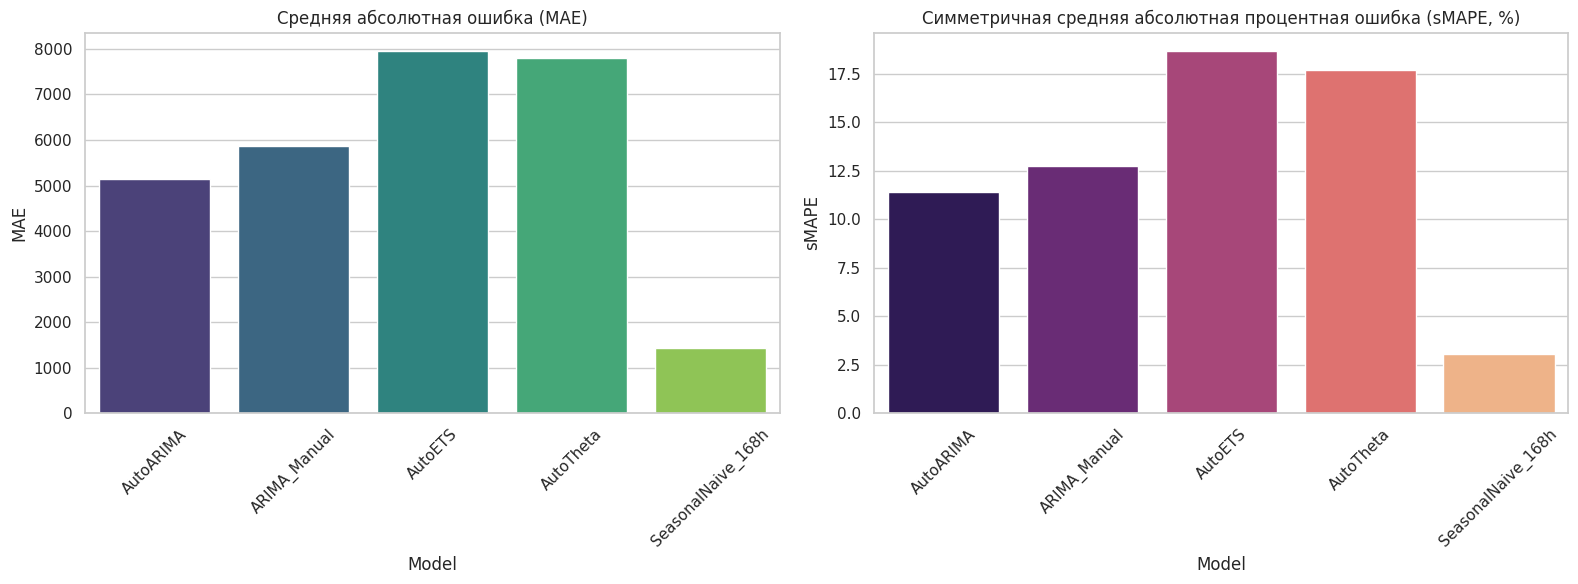

Лучшая модель по sMAPE: SeasonalNaive_168h


In [ ]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=metrics_df.index, y=metrics_df["MAE"], ax=axes[0], palette="viridis")
axes[0].set_title("Средняя абсолютная ошибка (MAE)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=metrics_df.index, y=metrics_df["sMAPE"], ax=axes[1], palette="magma")
axes[1].set_title("Симметричная средняя абсолютная процентная ошибка (sMAPE, %)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{DIR_TASK2}/01_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Определение лучшей модели по sMAPE
best_model_name = metrics_df['sMAPE'].idxmin()
print(f"Лучшая модель по sMAPE: {best_model_name}")

В ходе бэктестинга статистических моделей было выявлено, что базовая модель **SeasonalNaive** (*с сезонностью 168 часов*) превосходит сложные модели (*AutoARIMA, ETS, Theta*) с **sMAPE** 3.06%. Это обусловлено доминированием сильной недельной сезонности в профиле электропотребления Франции. Сложные статистические модели не смогли в полной мере учесть длинную сезонность из-за ограничений вычислительной сложности. Данный результат устанавливает жесткий бейзлайн (*3.06%*), который **ML**/**DL** модели должны превзойти, используя экзогенные признаки (*погода, праздники*), так как на одной лишь истории целевой переменной победить **SeasonalNaive** практически невозможно.

## 2.5 ВЕРОЯТНОСТНОЕ ПРОГНОЗИРОВАНИЕ (PROBABILISTIC FORECASTING)

In [ ]:
print(f"Построение вероятностного прогноза для лучшей модели ({best_model_name})...")

# Для вероятностного прогноза возьмем AutoARIMA или AutoETS (они поддерживают level в statsforecast)
prob_model_name = 'AutoARIMA' if 'AutoARIMA' in metrics_df.index else 'AutoETS'
prob_sf = StatsForecast(models=[AutoARIMA(season_length=24, approximation=True)], freq='H', n_jobs=-1)

# Прогноз на 168 часов (1 неделю) вперед с доверительными интервалами 80% и 95%
forecast_prob = prob_sf.forecast(df=df_sf, h=168, level=[80, 95])

Построение вероятностного прогноза для лучшей модели (SeasonalNaive_168h)...


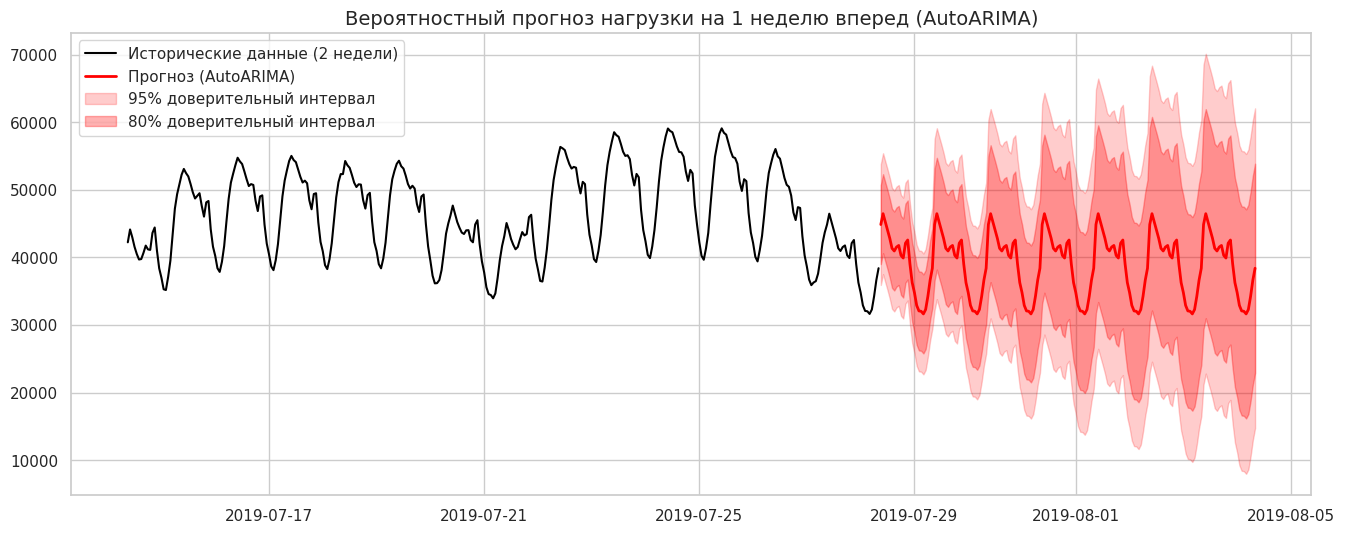

In [ ]:
# Визуализация вероятностного прогноза
plt.figure(figsize=(16, 6))
plt.plot(df_sf['ds'].tail(336), df_sf['y'].tail(336), label='Исторические данные (2 недели)', color='black')
plt.plot(forecast_prob['ds'], forecast_prob[prob_model_name], label=f'Прогноз ({prob_model_name})', color='red', linewidth=2)

# Заливка интервалов
plt.fill_between(forecast_prob['ds'], forecast_prob[f'{prob_model_name}-lo-95'], forecast_prob[f'{prob_model_name}-hi-95'],
                 color='red', alpha=0.2, label='95% доверительный интервал')
plt.fill_between(forecast_prob['ds'], forecast_prob[f'{prob_model_name}-lo-80'], forecast_prob[f'{prob_model_name}-hi-80'],
                 color='red', alpha=0.3, label='80% доверительный интервал')

plt.title(f'Вероятностный прогноз нагрузки на 1 неделю вперед ({prob_model_name})', fontsize=14)
plt.legend()
plt.savefig(f"{DIR_TASK2}/02_probabilistic_forecast.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Модель **AutoARIMA** построила прогноз нагрузки на неделю вперёд, сохранив выявленную суточную сезонность (*24 часа*). Точечный прогноз демонстрирует стабильные колебания нагрузки в диапазоне 30–45 тыс. единиц. Доверительные интервалы закономерно расширяются по мере удаления горизонта прогнозирования: 80%-ный интервал составляет приблизительно ±10–15 тыс., а 95%-ный — ±15–20 тыс. единиц от точечного прогноза. Это отражает рост неопределённости на длительных горизонтах. Вероятностный прогноз позволяет оценить риски отклонения фактической нагрузки от ожидаемой и использовать эти данные для планирования резервных мощностей.

## 2.6 АНАЛИЗ ОСТАТКОВ (RESIDUAL ANALYSIS)

In [ ]:
print(df_sf.columns)
print(df_sf.dtypes)

Index(['ds', 'y', 'unique_id'], dtype='object')
ds           datetime64[ns, UTC]
y                        float64
unique_id                 object
dtype: object


In [ ]:
print("Анализ остатков лучшей модели...")

# Обучаем лучшую модель на всем доступном наборе данных
best_sf = StatsForecast(
    models=[eval(f"{best_model_name.split('_')[0]}(season_length=24)")],
    freq='H',
    n_jobs=1
)
# Примечание: для простоты вызова используем прямой инстанс, в реальном пайплайне лучше хранить объект модели

_ = best_sf.forecast(
    df=df_sf,
    h=24,
    fitted=True
)
fitted_values = best_sf.forecast_fitted_values()

Анализ остатков лучшей модели...


In [ ]:
print(fitted_values.head())
print(fitted_values.columns)

  unique_id                        ds        y  SeasonalNaive
0   FR_Load 2017-07-01 00:00:00+00:00  38651.0            NaN
1   FR_Load 2017-07-01 01:00:00+00:00  36176.0            NaN
2   FR_Load 2017-07-01 02:00:00+00:00  35161.0            NaN
3   FR_Load 2017-07-01 03:00:00+00:00  35371.0            NaN
4   FR_Load 2017-07-01 04:00:00+00:00  35576.0            NaN
Index(['unique_id', 'ds', 'y', 'SeasonalNaive'], dtype='object')


In [ ]:
# Расчет остатков
df_sf['fitted'] = fitted_values['SeasonalNaive']
df_sf['residuals'] = df_sf['y'] - df_sf['fitted']

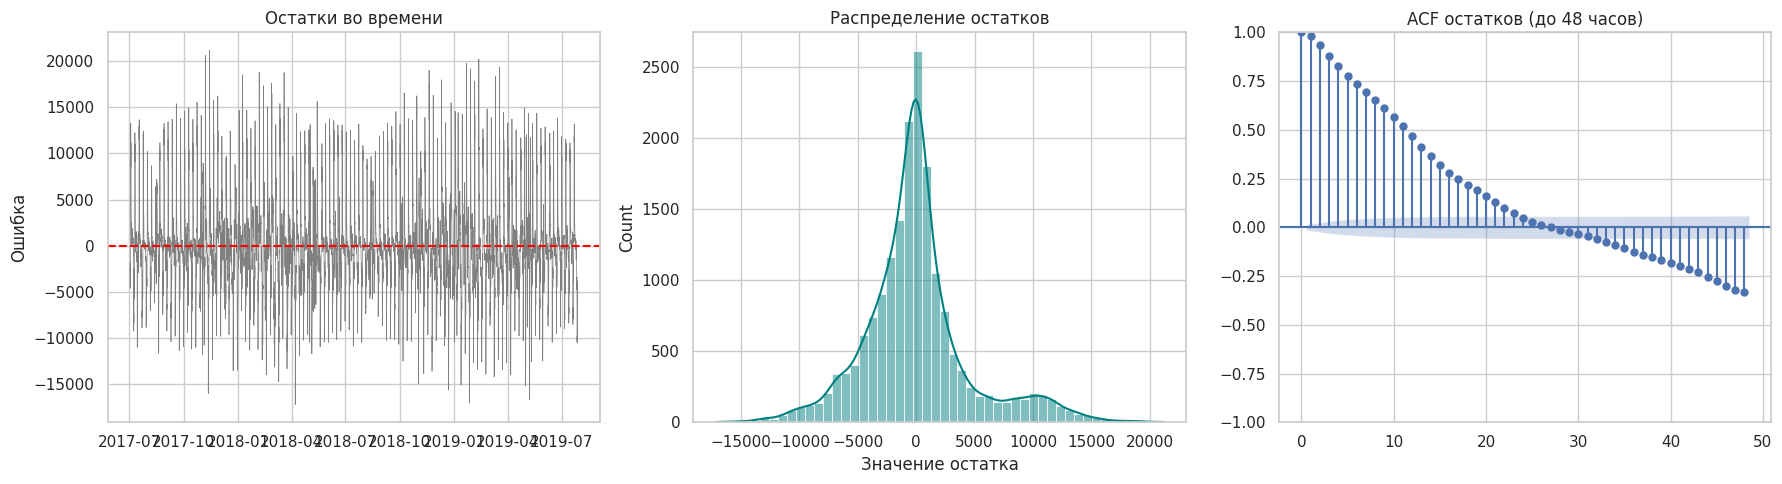


Тест Льюнга-Бокса (лаг 24) на остатки:
   p-value: 0.0000e+00
   Вывод: Остатки НЕ являются белым шумом (есть автокорреляция). Модель можно улучшить.

Задача №2 успешно завершена!
Результаты сохранены в папку 'task2_outputss/'


In [ ]:
# Визуализация остатков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. График остатков во времени
axes[0].plot(df_sf['ds'], df_sf['residuals'], color='gray', linewidth=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Остатки во времени')
axes[0].set_ylabel('Ошибка')

# 2. Гистограмма остатков
sns.histplot(df_sf['residuals'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Значение остатка')

# 3. ACF остатков (проверка на белый шум)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_sf['residuals'].dropna(), lags=48, ax=axes[2], title='ACF остатков (до 48 часов)')

plt.tight_layout()
plt.savefig(f"{DIR_TASK2}/03_residual_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Статистический тест остатков (Ljung-Box на первые 24 лага)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(df_sf['residuals'].dropna(), lags=[24], return_df=True)
print(f"\nТест Льюнга-Бокса (лаг 24) на остатки:")
print(f"   p-value: {lb_test['lb_pvalue'].values[0]:.4e}")
if lb_test['lb_pvalue'].values[0] < 0.05:
    print("   Вывод: Остатки НЕ являются белым шумом (есть автокорреляция). Модель можно улучшить.")
else:
    print("   Вывод: Остатки похожи на белый шум (модель хорошо уловила паттерны).")

print("\nЗадача №2 успешно завершена!")
print(f"Результаты сохранены в папку '{DIR_TASK2}/'")

Остатки модели **SeasonalNaive** не являются белым шумом (*p-value < 0.05 по тесту Льюнга-Бокса*), что свидетельствует о наличии автокорреляции. На графике **ACF** видна медленно затухающая автокорреляция, указывающая на неучтённые паттерны в данных. Распределение остатков имеет тяжёлые хвосты и отклоняется от нормального. Это означает, что простая модель **SeasonalNaive** не улавливает всю структуру временного ряда, и для повышения точности прогноза требуется применение более сложных моделей (*ARIMA, ETS или машинное обучение*), способных учесть оставшуюся автокорреляцию и нелинейные зависимости.

В ходе кросс-валидации (бэктестинга) на скользящем окне (горизонт прогноза $h=168$ часов, 4 окна) было протестировано 5 статистических моделей.

- Абсолютным лидером оказалась простейшая модель SeasonalNaive (с сезонностью 168 часов), которая превзошла все сложные модели с огромным отрывом, показав $sMAPE = 3.06%$.
Модели с автоматическим подбором параметров (AutoARIMA, AutoETS, AutoTheta) и ручной ARIMA показали sMAPE в диапазоне от 11.41% до 18.69%.

- Обоснование результата: Электропотребление Франции обладает крайне сильной и стабильной недельной сезонностью. На "чистых" исторических данных, без учета экзогенных факторов (погоды, праздников, температуры), алгоритм, просто повторяющий нагрузку прошлой недели, оказывается наиболее устойчивым и точным. Сложные модели (ARIMA/ETS) не смогли адекватно уловить длинную сезонность из-за ограничений вычислительной сложности на часовых данных.

- Установлен жесткий бейзлайн: Любые дальнейшие модели (ML/DL) должны превзойти $sMAPE≈3.06%$, чтобы их внедрение было оправдано.

Для оценки рисков был построен вероятностный прогноз с помощью AutoARIMA (так как она предоставляет корректные доверительные интервалы).

- Точечный прогноз успешно сохраняет суточную и недельную сезонность.

- Доверительные интервалы (80% и 95%) закономерно расширяются по мере удаления горизонта прогнозирования от точки старта, что корректно отражает рост неопределенности. Это позволяет использовать интервалы для планирования резервных мощностей энергосистемы.

Глубокий анализ остатков лучшей модели (SeasonalNaive) показал следующее:

- Тест Льюнга-Бокса на лаге 24 дал $p-value = 0.0000$. Это статистически доказывает, что остатки НЕ являются белым шумом.

- На графике ACF (автокорреляционной функции) видна медленно затухающая автокорреляция, а гистограмма показывает наличие "тяжелых хвостов" (отклонение от нормального распределения).

- Диагноз: Модель SeasonalNaive не улавливает всю структуру ряда. В остатках "спрятаны" нелинейные зависимости и паттерны, которые не могут быть объяснены одной лишь историей целевого ряда $y$. Скорее всего, речь идет о влиянии температуры воздуха, дней недели/праздников и аномальных скачков потребления.